In [1]:
import math
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from wandb.apis.public.runs import Run

import wandb

In [2]:
api = wandb.Api()

In [3]:
runs = api.runs("graphcore/llama-mobile", filters={"config.name": "lr-sweep-v2"})

In [4]:
def cleanup_run(run: Run) -> dict[str, Any]:
    d = {}

    d["batch_size"] = run.config["training"]["batch_size"]
    d["n_steps"] = run.config["training"]["n_steps"]
    d["beta1"] = run.config["training"]["optimiser"]["betas"][0]
    d["beta2"] = run.config["training"]["optimiser"]["betas"][1]
    d["lr_exponent"] = math.log2(run.config["training"]["optimiser"]["lr"])

    history = run.history()
    d["train_loss"] = np.mean(history["train/loss"].tail(10).values)
    d["val_loss"] = run.summary["val/loss"]
    d["step_time"] = np.mean(history["perf/step_time"].values)

    return d

In [5]:
df = pd.DataFrame([cleanup_run(run) for run in runs])
df.sort_values(by="val_loss", ascending=True, inplace=True)

True
True
True
True
True
True
True


In [6]:
# NOTE: 2**-13 learning rate explodes, so exclude
df

,batch_size,n_steps,beta1,beta2,lr_exponent,train_loss,val_loss,step_time
3,64,256,0.9,0.999,-16.0,0.042481,0.044457,25.512008
2,64,256,0.9,0.999,-17.0,0.046806,0.048667,25.242926
4,64,256,0.9,0.999,-15.0,0.047072,0.051875,25.470303
1,64,256,0.9,0.999,-18.0,0.050984,0.052764,25.553852
0,64,256,0.9,0.999,-19.0,0.059806,0.061473,26.096932
5,64,256,0.9,0.999,-14.0,0.060214,0.063550,25.425685
6,64,256,0.9,0.999,-13.0,4.828126,4.948041,25.340281


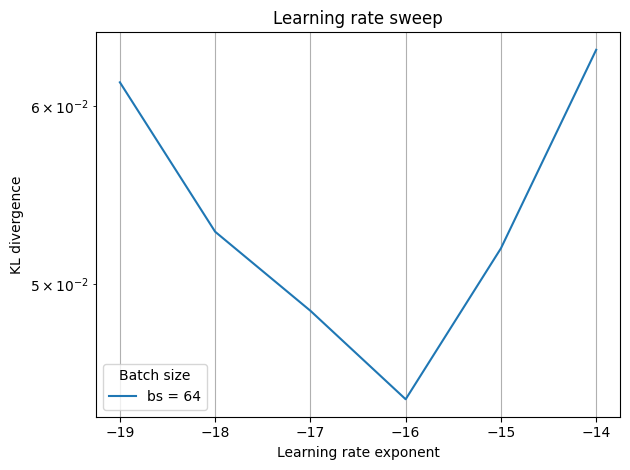

In [7]:
for bs, group in df[df["val_loss"] < 1].groupby("batch_size"):
    group_sorted = group.sort_values('lr_exponent')
    plt.plot(group_sorted["lr_exponent"], group_sorted["val_loss"], label=f"bs = {bs}")
    plt.yscale("log")
    
plt.title("Learning rate sweep")
plt.xlabel("Learning rate exponent")
plt.ylabel("KL divergence")
plt.legend(title="Batch size")
plt.grid(True)
plt.tight_layout()